# Calibration inspection

Plots real, synthetic (uncalibrated), and calibrated IMU signals for a single capture.
The real signal is downsampled to the virtual FPS before plotting so amplitudes are comparable.

In [14]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import importlib
import numpy as np
import matplotlib.pyplot as plt
import evaluation.utils as utils_module
utils_module = importlib.reload(utils_module)

plt.style.use("seaborn-v0_8-whitegrid")

In [15]:
# --- configuration -----------------------------------------------------------
OUTPUT_ROOT       = PROJECT_ROOT / "output" / "robot_emotions_virtual_imu"
DOMAIN            = "10ms"
USER_ID           = 2
TAG_NUMBER        = 1
TAKE_ID           = None
SIGNAL_GROUP      = "acc"          # "acc" or "gyro"
SENSOR_NAME       = "right_forearm"        # single sensor: "waist", "head", "right_forearm", "left_forearm"
TIME_RANGE_SEC    = None           # None = full clip, or e.g. (5.0, 15.0)
CALIBRATION_FRACTION = 0.1        # fraction of real IMU clip used as calibration reference
FIGSIZE           = (13, 5)
LINE_WIDTH        = 1.2
# -----------------------------------------------------------------------------

CAPTURES_DF = utils_module.build_exported_capture_table(OUTPUT_ROOT)
capture_row = utils_module.select_capture_row(
    CAPTURES_DF, domain=DOMAIN, user_id=USER_ID, tag_number=TAG_NUMBER, take_id=TAKE_ID
)

clip_dir = Path(capture_row["clip_dir"])
pose_dir = Path(capture_row["pose_dir"])
print("clip_id:", capture_row["clip_id"])
print("clip_dir:", clip_dir)
print("pose_dir:", pose_dir)

clip_id: robot_emotions_10ms_u02_tag01
clip_dir: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu/10ms/user_02/robot_emotions_10ms_u02_tag01
pose_dir: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu/10ms/user_02/robot_emotions_10ms_u02_tag01/pose/virtual_imu


In [16]:
from pose_module.processing.frequency_alignment import prepare_real_signal_for_virtual_comparison
from pose_module.processing.imu_calibration import build_calibration_reference_matrix, calibrate_virtual_imu_sequence
from pose_module.interfaces import VirtualIMUSequence

CHANNEL_GROUP_TO_LABELS = {"acc": ("ax", "ay", "az"), "gyro": ("gx", "gy", "gz")}
COLORS = {"real": "#2196F3", "virtual": "#FF5722", "calibrated": "#4CAF50"}

real_data = utils_module.load_real_capture(clip_dir)
virt_data = utils_module.load_virtual_capture(pose_dir, filename="virtual_imu.npz")

# --- on-the-fly calibration using CALIBRATION_FRACTION ----------------------
real_imu_path = str(clip_dir / "imu.npz")
selected_sensors = list(virt_data["sensor_names"])

real_matrix = build_calibration_reference_matrix(
    clip_npz_paths=[real_imu_path],
    target_sensor_names=selected_sensors,
    signal_mode="acc",
    calibration_fraction=CALIBRATION_FRACTION,
)

import tempfile, os
_tmp = tempfile.NamedTemporaryFile(suffix=".npz", delete=False)
_tmp.close()
try:
    np.savez(_tmp.name,
             acc=real_matrix.reshape(real_matrix.shape[0], len(selected_sensors), -1),
             sensor_names=np.array(selected_sensors))

    seq = VirtualIMUSequence(
        clip_id=str(capture_row["clip_id"]),
        fps=None,
        sensor_names=selected_sensors,
        acc=virt_data["acc"],
        gyro=virt_data["gyro"],
        timestamps_sec=virt_data["timestamps_sec"],
        source="uncalibrated",
    )
    _cal_result = calibrate_virtual_imu_sequence(
        seq,
        real_imu_reference_path=_tmp.name,
        signal_mode="acc",
    )
finally:
    os.unlink(_tmp.name)

cal_data = {
    "acc": np.asarray(_cal_result["virtual_imu_sequence"].acc, dtype=np.float32),
    "gyro": virt_data["gyro"],
    "timestamps_sec": virt_data["timestamps_sec"],
    "sensor_names": virt_data["sensor_names"],
}
print(f"Calibration fraction: {CALIBRATION_FRACTION}")
# ---------------------------------------------------------------------------

real_slice = slice(0, 3) if SIGNAL_GROUP == "acc" else slice(3, 6)
real_values = real_data["imu"][:, :, real_slice]  # [T, S, 3]

real_bundle = prepare_real_signal_for_virtual_comparison(
    real_timestamps_sec=real_data["timestamps_sec"],
    real_values=real_values,
    virtual_timestamps_sec=virt_data["timestamps_sec"],
)
real_t   = real_bundle["timestamps_sec"]
real_acc = real_bundle["values"]

virt_t   = virt_data["timestamps_sec"]
virt_acc = virt_data[SIGNAL_GROUP]
cal_acc  = cal_data[SIGNAL_GROUP]

utils_module.resolve_selected_sensors([SENSOR_NAME], real_data["sensor_names"])
utils_module.resolve_selected_sensors([SENSOR_NAME], virt_data["sensor_names"])
real_name_to_idx = {n: i for i, n in enumerate(real_data["sensor_names"])}
virt_name_to_idx = {n: i for i, n in enumerate(virt_data["sensor_names"])}

freq_summary = real_bundle["summary"]
print(f"Real original:  {freq_summary['real_original_frequency_hz']:.1f} Hz → downsampled to {freq_summary['real_plot_frequency_hz']:.1f} Hz")
print(f"Virtual:        {freq_summary['virtual_frequency_hz']:.1f} Hz")
print(f"Sensor:         {SENSOR_NAME}")

Calibration fraction: 0.1
Real original:  111.1 Hz → downsampled to 30.0 Hz
Virtual:        30.0 Hz
Sensor:         right_forearm


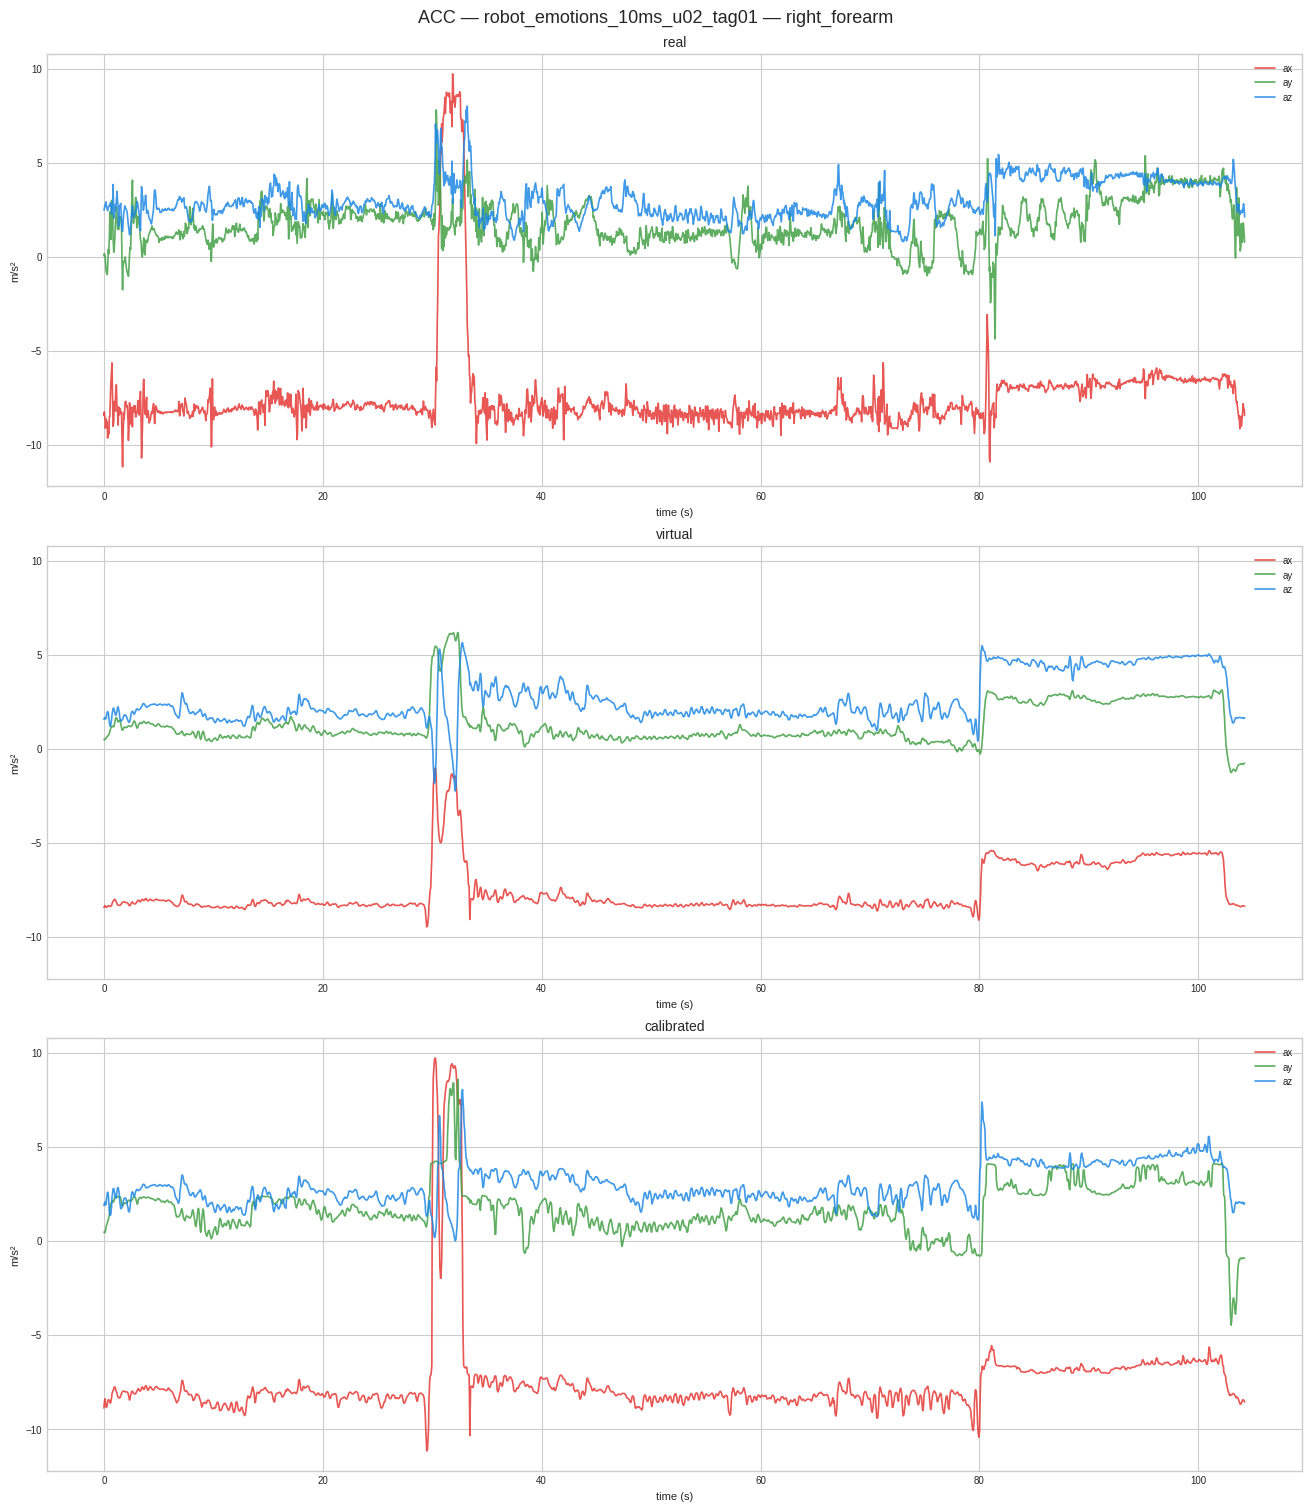

In [17]:
# Time-series: 3 rows x 1 col (real / virtual / calibrated) — x/y/z overlaid per subplot
component_labels = CHANNEL_GROUP_TO_LABELS[SIGNAL_GROUP]
unit = "m/s²" if SIGNAL_GROUP == "acc" else "rad/s"
ri = real_name_to_idx[SENSOR_NAME]
vi = virt_name_to_idx[SENSOR_NAME]

AXIS_COLORS = {"ax": "#E53935", "ay": "#43A047", "az": "#1E88E5",
               "gx": "#E53935", "gy": "#43A047", "gz": "#1E88E5"}

signals = [
    ("real",       real_t,  real_acc[:, ri, :], COLORS["real"]),
    ("virtual",    virt_t,  virt_acc[:, vi, :], COLORS["virtual"]),
    ("calibrated", virt_t,  cal_acc[:, vi, :],  COLORS["calibrated"]),
]

# Global y-limits across all signals and components
all_vals = []
for _, t, vals, _ in signals:
    for col in range(3):
        _, v = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        all_vals.append(v)
g_min = min(v.min() for v in all_vals)
g_max = max(v.max() for v in all_vals)
g_margin = (g_max - g_min) * 0.05
ylim = (g_min - g_margin, g_max + g_margin)

fig, axes = plt.subplots(3, 1, figsize=(FIGSIZE[0], FIGSIZE[1] * 3), sharey=True, constrained_layout=True)
fig.suptitle(f"{SIGNAL_GROUP.upper()} — {capture_row['clip_id']} — {SENSOR_NAME}", fontsize=13)

for ax, (label, t, vals, _) in zip(axes, signals):
    for col, comp in enumerate(component_labels):
        t_plot, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax.plot(t_plot, v_plot, color=AXIS_COLORS[comp], lw=LINE_WIDTH, label=comp, alpha=0.85)
    ax.set_ylim(ylim)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(unit, fontsize=8)
    ax.set_xlabel("time (s)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.show()

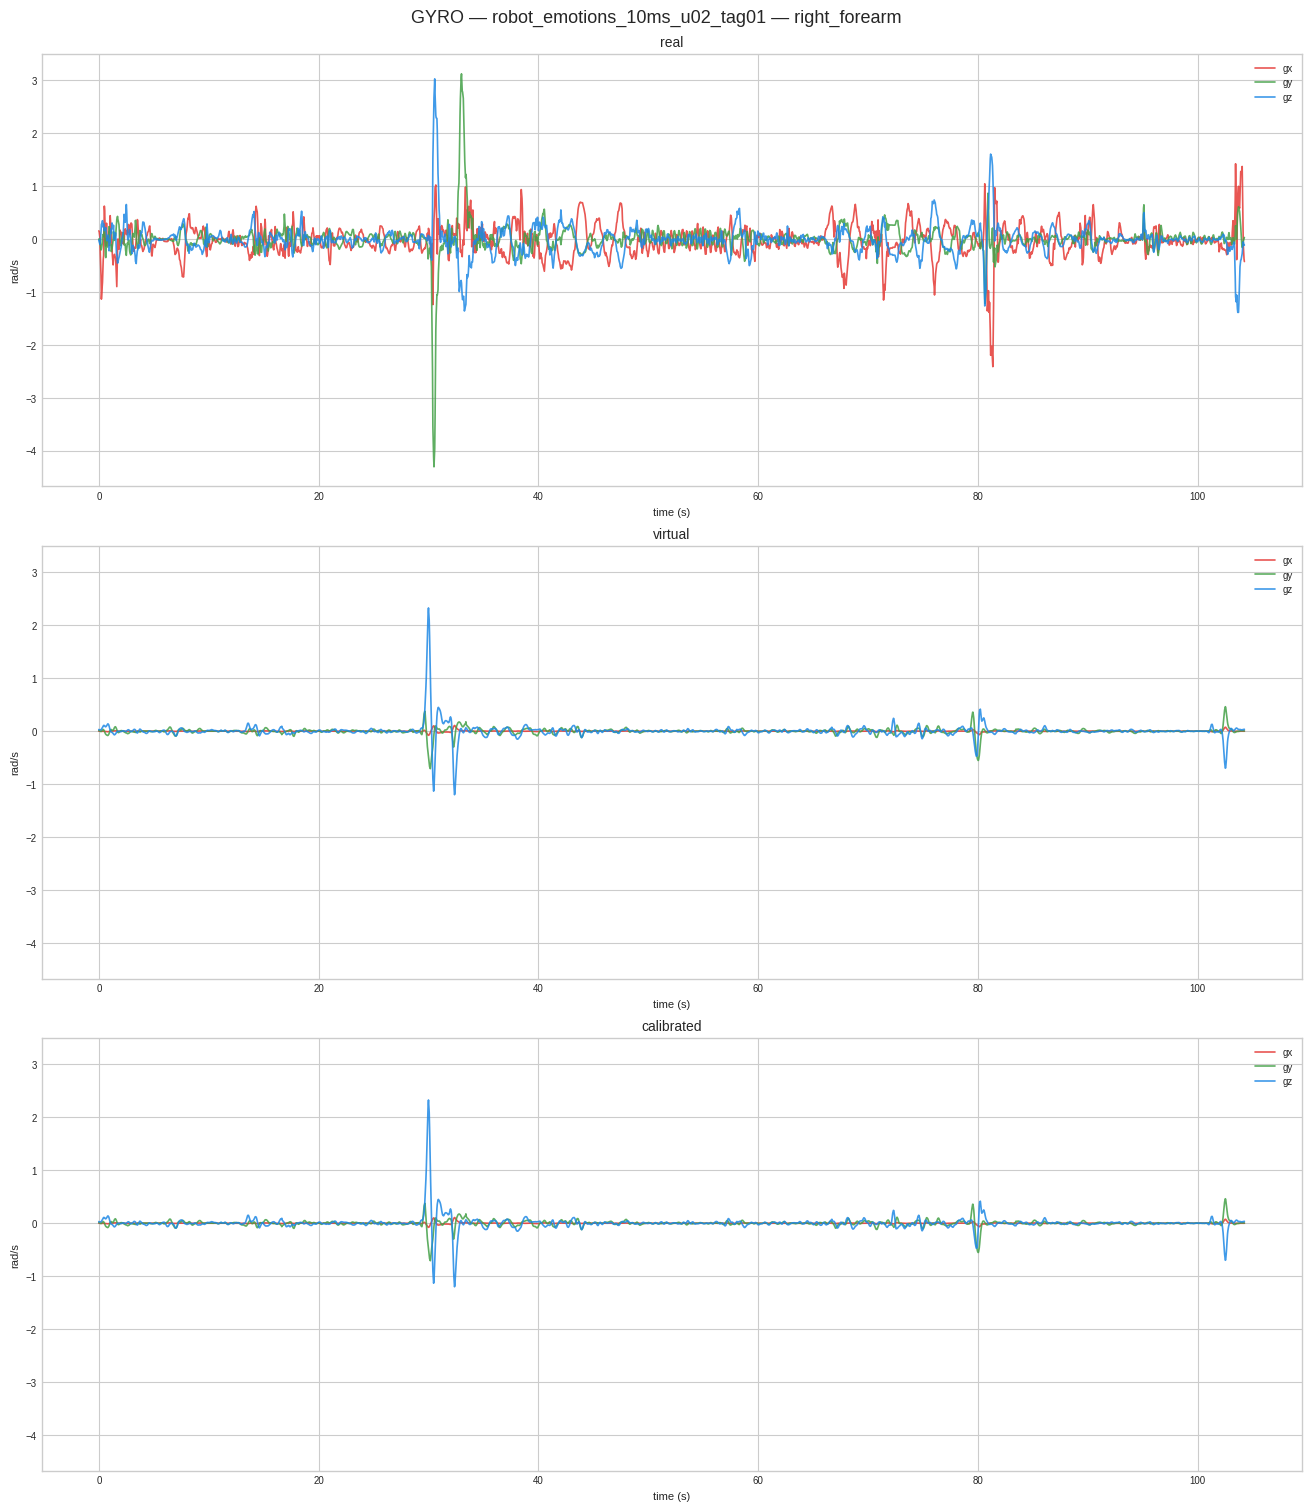

In [18]:
# Time-series gyro: 3 rows x 1 col (real / virtual / calibrated) — gx/gy/gz overlaid per subplot
gyro_labels = CHANNEL_GROUP_TO_LABELS["gyro"]
gyro_unit = "rad/s"

real_gyro_values = real_data["imu"][:, :, 3:6]  # [T, S, 3]
real_gyro_bundle = prepare_real_signal_for_virtual_comparison(
    real_timestamps_sec=real_data["timestamps_sec"],
    real_values=real_gyro_values,
    virtual_timestamps_sec=virt_data["timestamps_sec"],
)
real_gyro = real_gyro_bundle["values"]

gyro_signals = [
    ("real",       real_t,  real_gyro[:, ri, :],          COLORS["real"]),
    ("virtual",    virt_t,  virt_data["gyro"][:, vi, :],  COLORS["virtual"]),
    ("calibrated", virt_t,  cal_data["gyro"][:, vi, :],   COLORS["calibrated"]),
]

all_gyro_vals = []
for _, t, vals, _ in gyro_signals:
    for col in range(3):
        _, v = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        all_gyro_vals.append(v)
g_min = min(v.min() for v in all_gyro_vals)
g_max = max(v.max() for v in all_gyro_vals)
g_margin = (g_max - g_min) * 0.05
gyro_ylim = (g_min - g_margin, g_max + g_margin)

fig, axes = plt.subplots(3, 1, figsize=(FIGSIZE[0], FIGSIZE[1] * 3), sharey=True, constrained_layout=True)
fig.suptitle(f"GYRO — {capture_row['clip_id']} — {SENSOR_NAME}", fontsize=13)

for ax, (label, t, vals, _) in zip(axes, gyro_signals):
    for col, comp in enumerate(gyro_labels):
        t_plot, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax.plot(t_plot, v_plot, color=AXIS_COLORS[comp], lw=LINE_WIDTH, label=comp, alpha=0.85)
    ax.set_ylim(gyro_ylim)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel(gyro_unit, fontsize=8)
    ax.set_xlabel("time (s)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.show()

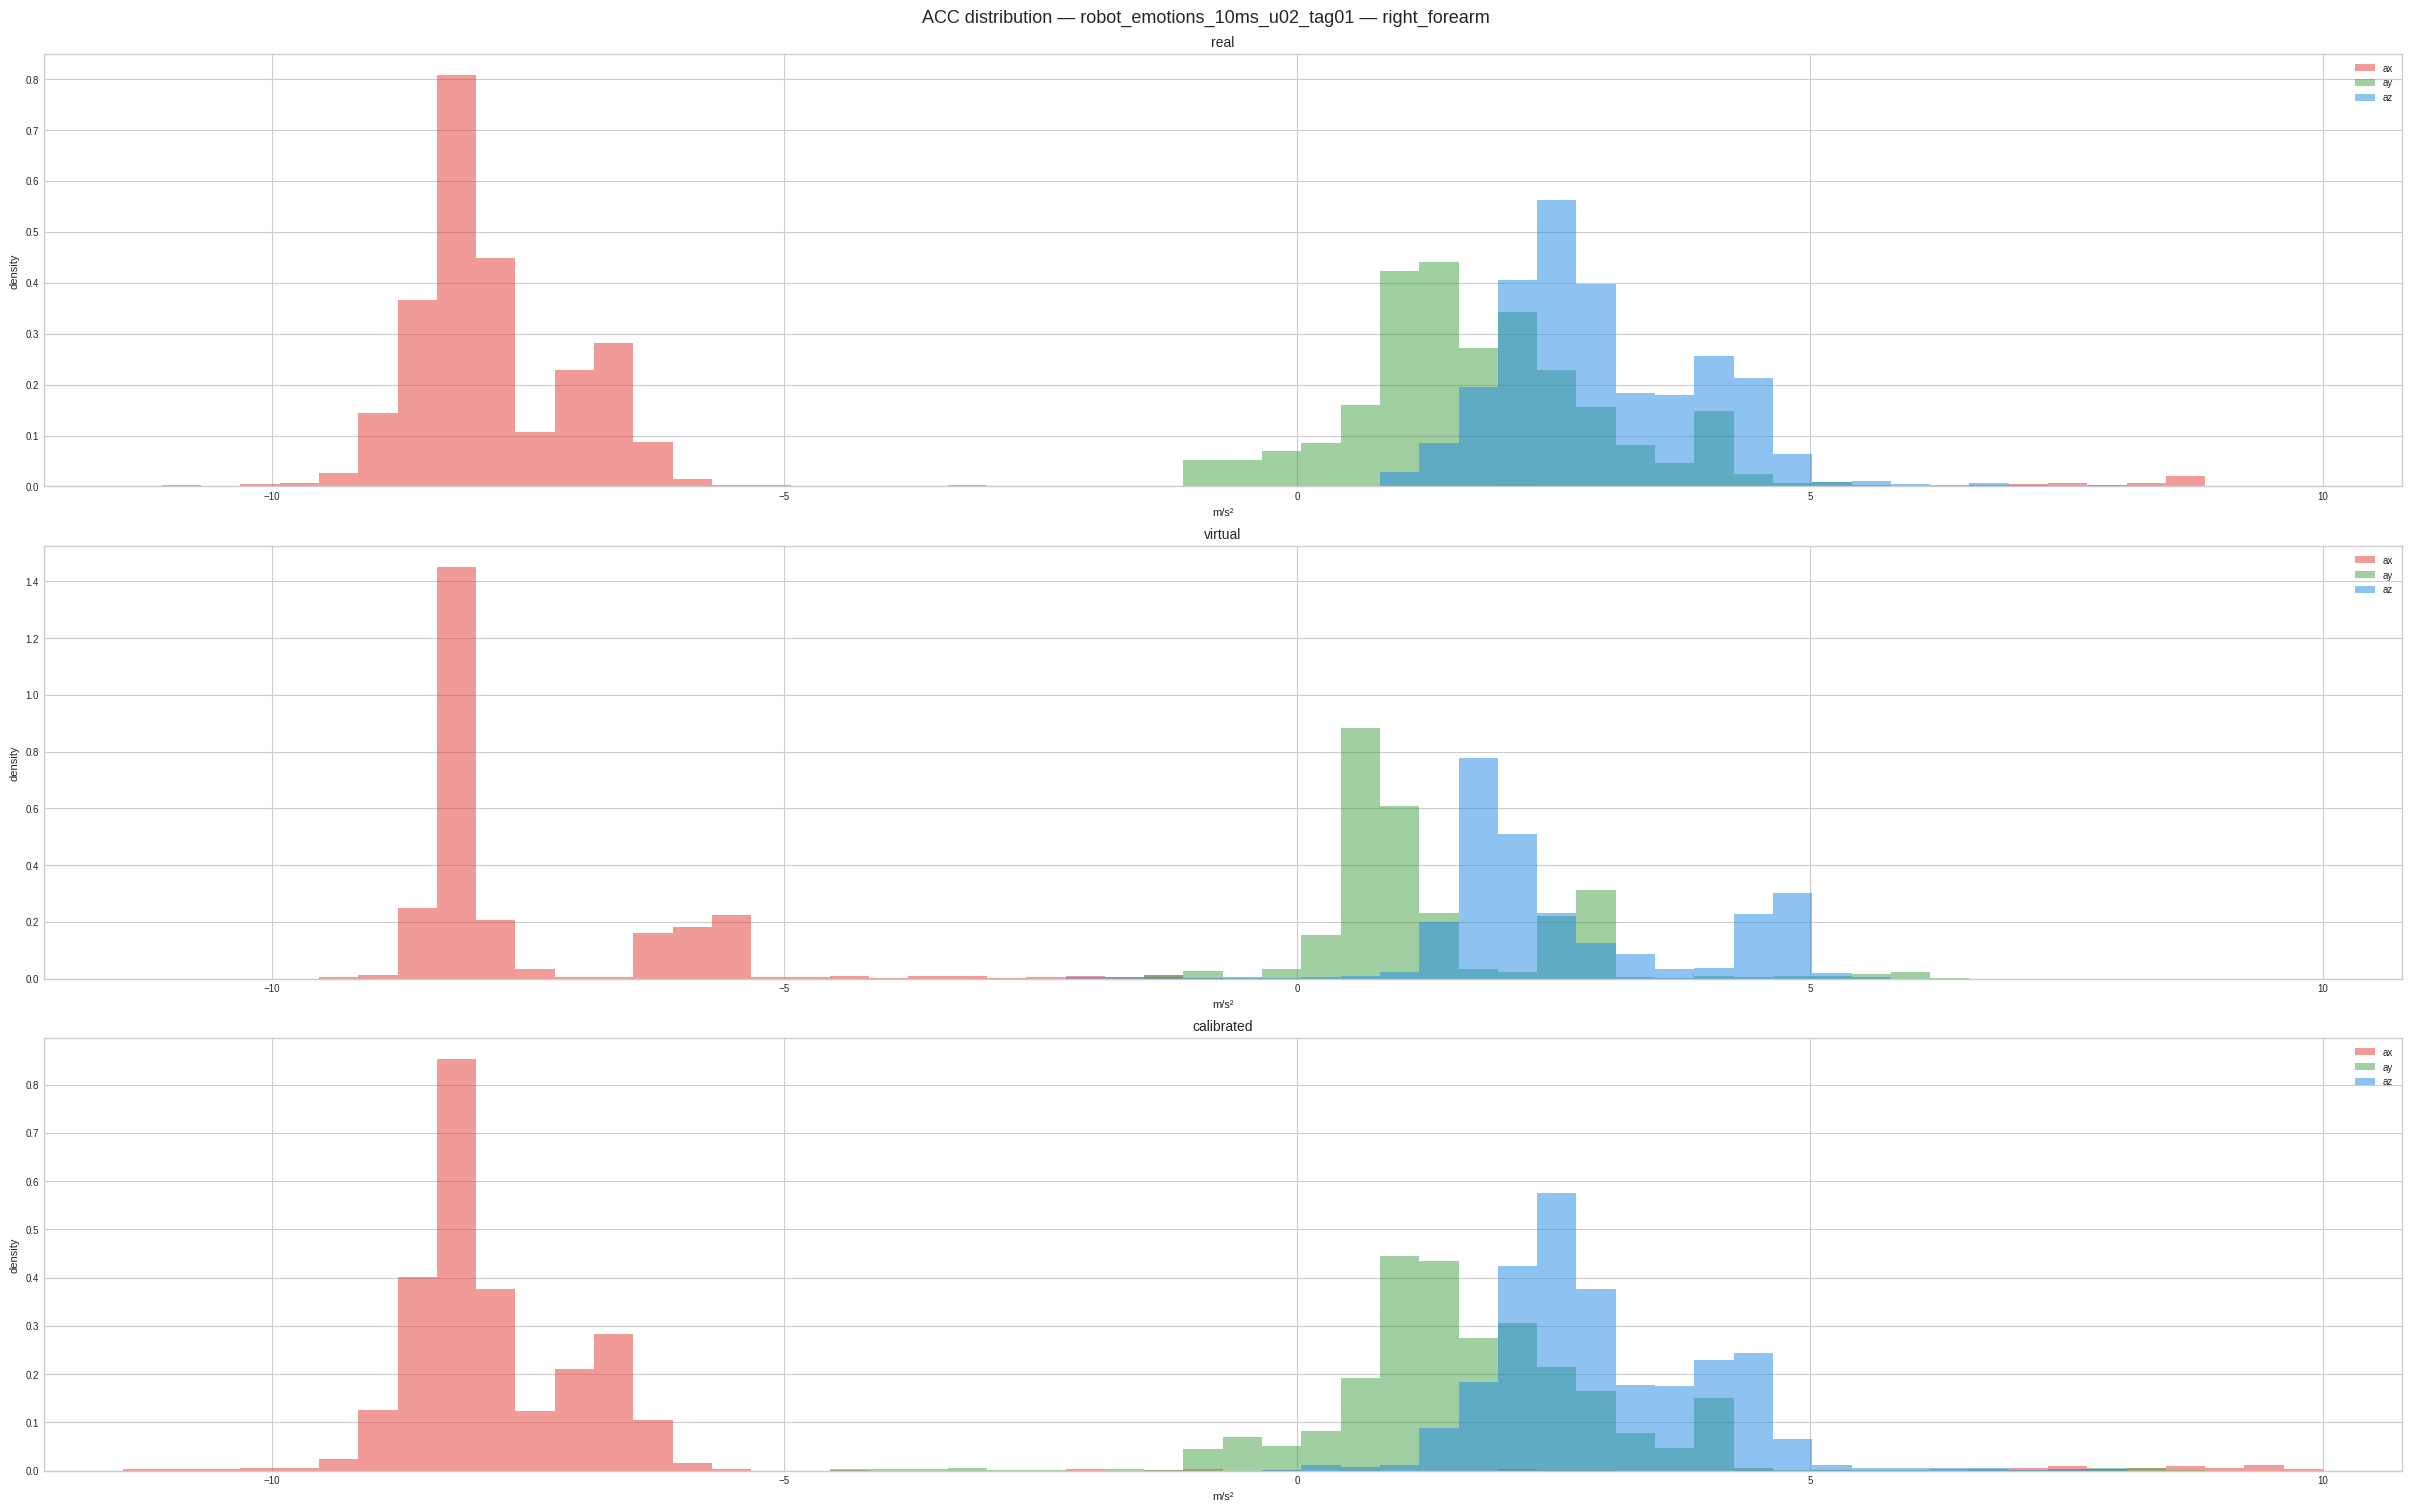

In [19]:
# Distribution (histogram): 3 rows x 1 col (real / virtual / calibrated) — x/y/z overlaid per subplot
all_flat = []
for _, t, vals, _ in signals:
    for col in range(3):
        _, v = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        all_flat.append(v)
g_min = min(v.min() for v in all_flat)
g_max = max(v.max() for v in all_flat)
g_margin = (g_max - g_min) * 0.05
xlim = (g_min - g_margin, g_max + g_margin)

fig, axes = plt.subplots(3, 1, figsize=(24, FIGSIZE[1] * 3), constrained_layout=True)
fig.suptitle(f"{SIGNAL_GROUP.upper()} distribution — {capture_row['clip_id']} — {SENSOR_NAME}", fontsize=13)

for ax, (label, t, vals, _) in zip(axes, signals):
    for col, comp in enumerate(component_labels):
        _, v = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax.hist(v, bins=60, color=AXIS_COLORS[comp], alpha=0.5, density=True, range=xlim, label=comp)
    ax.set_xlim(xlim)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(unit, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.show()

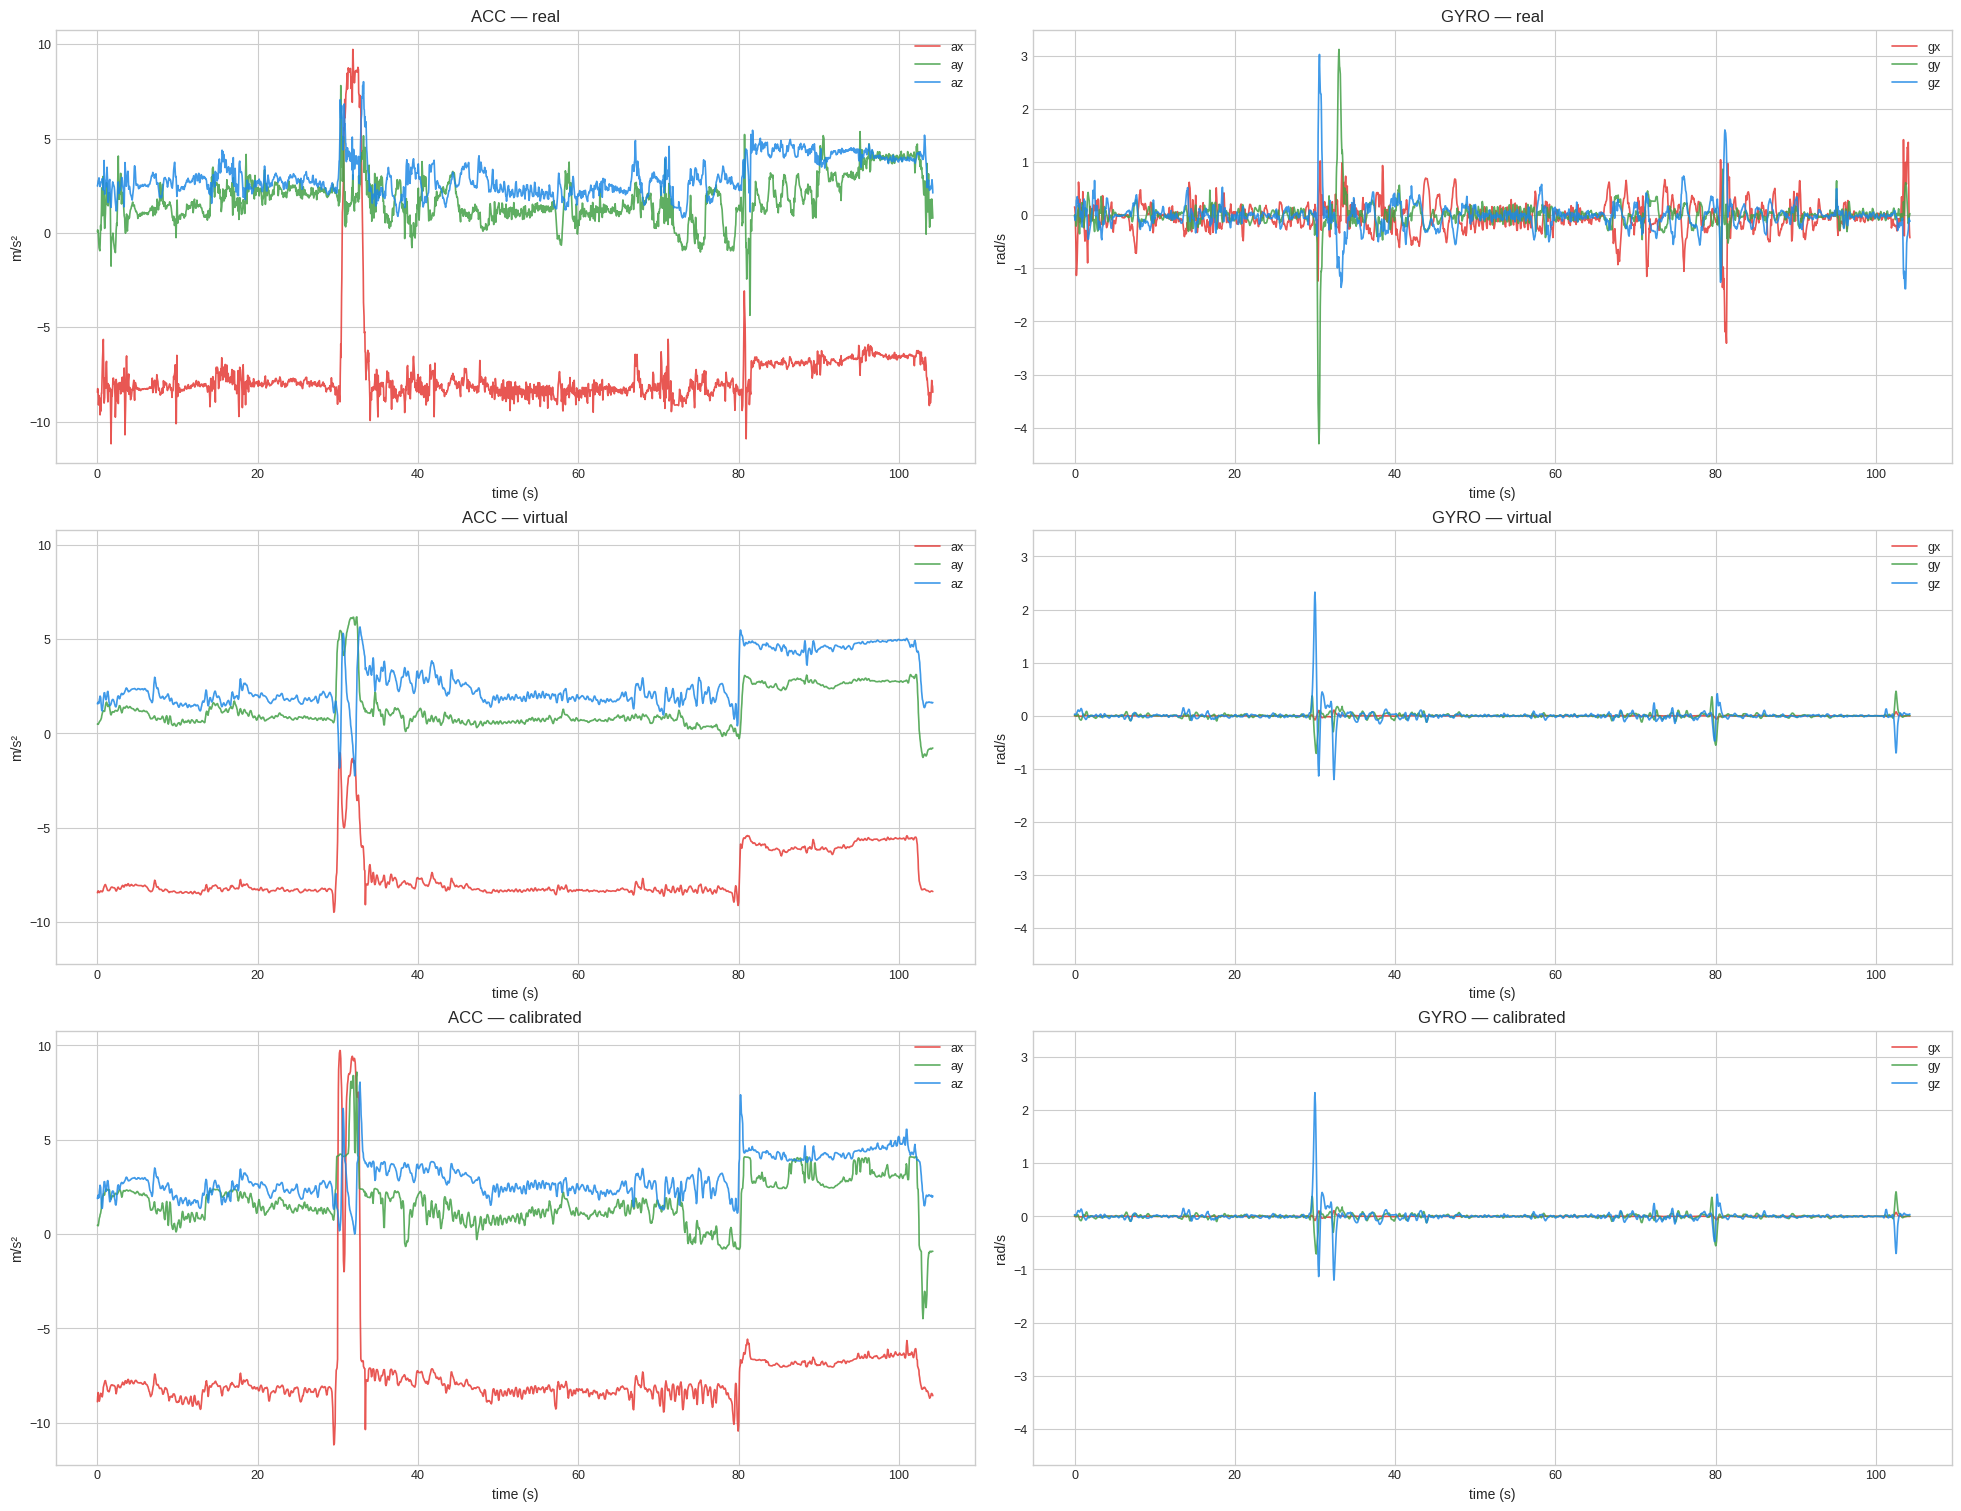

In [20]:
# Combined 2x3: rows = real / virtual / calibrated, cols = acc | gyro
row_labels = ["real", "virtual", "calibrated"]
acc_signals  = [(t, vals) for _, t, vals, _ in signals]
gyro_signals_vals = [(t, vals) for _, t, vals, _ in gyro_signals]

# Shared y-limits (each column uses its own scale)
def _ylim(signal_list):
    flat = [utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)[1]
            for t, vals in signal_list for col in range(3)]
    lo, hi = min(v.min() for v in flat), max(v.max() for v in flat)
    margin = (hi - lo) * 0.05
    return (lo - margin, hi + margin)

acc_ylim  = _ylim(acc_signals)
gyro_ylim_combined = _ylim(gyro_signals_vals)

fig, axes = plt.subplots(3, 2, figsize=(FIGSIZE[0] * 1.5, FIGSIZE[1] * 3),
                         sharey="col", constrained_layout=True)

for row, label in enumerate(row_labels):
    # --- ACC column (left) ---
    ax_acc = axes[row, 0]
    t, vals = acc_signals[row]
    for col, comp in enumerate(CHANNEL_GROUP_TO_LABELS["acc"]):
        t_plot, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax_acc.plot(t_plot, v_plot, color=AXIS_COLORS[comp], lw=LINE_WIDTH, label=comp, alpha=0.85)
    ax_acc.set_ylim(acc_ylim)
    ax_acc.set_title(f"ACC — {label}", fontsize=12)
    ax_acc.set_ylabel("m/s²", fontsize=10)
    ax_acc.set_xlabel("time (s)", fontsize=10)
    ax_acc.tick_params(labelsize=9)
    ax_acc.legend(fontsize=9)

    # --- GYRO column (right) ---
    ax_gyro = axes[row, 1]
    t, vals = gyro_signals_vals[row]
    for col, comp in enumerate(CHANNEL_GROUP_TO_LABELS["gyro"]):
        t_plot, v_plot = utils_module.apply_time_range(t, vals[:, col], TIME_RANGE_SEC)
        ax_gyro.plot(t_plot, v_plot, color=AXIS_COLORS[comp], lw=LINE_WIDTH, label=comp, alpha=0.85)
    ax_gyro.set_ylim(gyro_ylim_combined)
    ax_gyro.set_title(f"GYRO — {label}", fontsize=12)
    ax_gyro.set_ylabel("rad/s", fontsize=10)
    ax_gyro.set_xlabel("time (s)", fontsize=10)
    ax_gyro.tick_params(labelsize=9)
    ax_gyro.legend(fontsize=9)

plt.show()

In [22]:
pdf_path = PROJECT_ROOT / "output" / "imu_plots" / f"acc_gyro_combined_{capture_row['clip_id']}_{SENSOR_NAME}.pdf"
os.makedirs(pdf_path.parent, exist_ok=True)
fig.savefig(pdf_path, bbox_inches="tight")
print("Saved:", pdf_path)

Saved: /home/henriquesouza/POSE2IMU-Framework/output/imu_plots/acc_gyro_combined_robot_emotions_10ms_u02_tag01_right_forearm.pdf
